# 🧠 Building an MLP on MNIST — Step-by-Step Guided Notebook

**How to use this notebook:**
- Every `### YOUR CODE HERE ###` block is something you fill in.
- Read the hints carefully — they tell you *what* to write, not *how*.
- Every **Sanity Check** cell runs assertions. If it passes silently, you're good. If it throws, read the error and fix your code above.
- Don't skip cells — each one builds on the last.

---
> **Real-world note:** A Machine Learning Engineer never writes 200 lines at once. They write 10, check the shapes, check the values, print something, *then* move on. This notebook teaches that habit.

## Step 1 — Imports & Device Setup

Always the first cell. Import everything you'll need upfront so there are no surprises later.

**What to import:**
- `torch` and its submodules: `torch.nn`, `torch.optim`
- `torchvision.datasets` and `torchvision.transforms`
- `torch.utils.data.DataLoader`
- `wandb` for experiment tracking

**Device logic:**
PyTorch can run on different hardware backends. The priority order on a modern Mac is:
1. MPS (Apple Silicon GPU) — fastest on M1/M2/M3
2. CUDA (Nvidia GPU) — fastest on Linux/Windows with a GPU
3. CPU — always available, slowest

Pseudocode:
```
if mps is available → device = 'mps'
elif cuda is available → device = 'cuda'
else → device = 'cpu'
```

In [1]:
### YOUR CODE HERE ###
# 1. Import torch and submodules
import torch
import torch.nn as nn
import torch.optim as optim

# 2. Import torchvision components
from torchvision import datasets,transforms
from  torch.utils.data import DataLoader
# 3. Import wandb
import wandb

# 4. Set device using the priority logic above
device = (
    torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)

print(f"Using device: {device}")

Using device: mps


### ✅ Sanity Check 1 — Imports & Device

In [2]:
# SANITY CHECK — do not modify
import torch as _torch

assert 'torch' in dir(), "torch not imported"
assert 'nn' in dir(), "torch.nn not imported"
assert 'optim' in dir(), "torch.optim not imported"
assert 'DataLoader' in dir(), "DataLoader not imported"
assert 'wandb' in dir(), "wandb not imported"
assert isinstance(device, _torch.device), "device must be a torch.device object, not a string"
assert str(device) in ('cpu', 'cuda', 'mps'), f"Unexpected device: {device}"

print(f"✅ Sanity Check 1 passed — device is '{device}'")

✅ Sanity Check 1 passed — device is 'mps'


---
## Step 2 — Hyperparameters

Store all hyperparameters in a single dictionary called `CONFIG`. This is a professional habit:
- Makes it easy to change things in one place
- W&B can log the whole dict automatically
- Anyone reading your code immediately understands the experiment setup

**You need these keys:**
| Key | Suggested value | What it controls |
|---|---|---|
| `epochs` | 10 | How many full passes through the training data |
| `learning_rate` | 1e-3 | Step size for gradient descent |
| `hidden_dim` | 256 | Width of the first hidden layer |
| `batch_size` | 32 | Samples per gradient update |
| `dropout` | 0.3 | Fraction of neurons randomly zeroed during training |

In [3]:
### YOUR CODE HERE ###
CONFIG = {
    # fill in all 5 keys
    'epochs':10,
    'learning_rate':1e-3,
    'hidden_dim':256,
    'batch_size':32,
    'dropout':0.3,
}

print(CONFIG)

{'epochs': 10, 'learning_rate': 0.001, 'hidden_dim': 256, 'batch_size': 32, 'dropout': 0.3}


### ✅ Sanity Check 2 — CONFIG

In [4]:
# SANITY CHECK — do not modify
required_keys = {'epochs', 'learning_rate', 'hidden_dim', 'batch_size', 'dropout'}
assert required_keys.issubset(CONFIG.keys()), f"Missing keys: {required_keys - CONFIG.keys()}"
assert isinstance(CONFIG['epochs'], int) and CONFIG['epochs'] > 0
assert 0 < CONFIG['learning_rate'] < 1
assert isinstance(CONFIG['hidden_dim'], int) and CONFIG['hidden_dim'] > 0
assert isinstance(CONFIG['batch_size'], int) and CONFIG['batch_size'] > 0
assert 0.0 <= CONFIG['dropout'] < 1.0

print("✅ Sanity Check 2 passed — CONFIG looks good")

✅ Sanity Check 2 passed — CONFIG looks good


---
## Step 3 — Data Loading

This step has two parts: **transforms** and **datasets + dataloaders**.

### 3a. Transforms
A transform is a preprocessing pipeline applied to each image before it enters the model.

Use `transforms.Compose([...])` to chain:
1. `transforms.ToTensor()` — converts a PIL image (H×W, uint8) to a float tensor (1×H×W, range 0–1)
2. `transforms.Normalize((mean,), (std,))` — standardizes pixel values. For MNIST, use mean=`0.1307`, std=`0.3081`.

> **Why normalize?** Neural networks train much faster and more stably when inputs are roughly zero-centered with unit variance.

### 3b. Datasets
Use `datasets.MNIST(root, train, download, transform)`:
- `train=True` for training set (60,000 images)
- `train=False` for validation/test set (10,000 images)
- `root="./data"` — where to save downloaded files

### 3c. DataLoaders
A `DataLoader` wraps a dataset and serves batches.
- Training: `shuffle=True` (randomizes order each epoch)
- Validation: `shuffle=False` (order doesn't matter)
- Use `num_workers=0` to avoid multiprocessing issues on some systems

In [6]:
### YOUR CODE HERE ###
# 3a. Define transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=0.1307,std=0.3081)
])

# 3b. Create train and val datasets
train_dataset = datasets.MNIST(root='./data',train=True,download=True,transform=transform)
val_dataset   = datasets.MNIST(root='./data',train=False,download=True,transform=transform)

# 3c. Create dataloaders
train_dataloader = DataLoader(train_dataset,shuffle=True,batch_size=CONFIG['batch_size'],num_workers=0)
val_dataloader   = DataLoader(val_dataset,shuffle=False,batch_size=CONFIG['batch_size'],num_workers=0)

print(f"Train batches: {len(train_dataloader)} | Val batches: {len(val_dataloader)}")

Train batches: 1875 | Val batches: 313


### ✅ Sanity Check 3 — Data Pipeline

In [7]:
# SANITY CHECK — do not modify
import torch as _torch

# Check dataset sizes
assert len(train_dataset) == 60000, f"Expected 60000 train samples, got {len(train_dataset)}"
assert len(val_dataset)   == 10000, f"Expected 10000 val samples, got {len(val_dataset)}"

# Check a single sample
img, label = train_dataset[0]
assert img.shape == (1, 28, 28), f"Expected shape (1,28,28), got {img.shape}"
assert img.dtype == _torch.float32, f"Expected float32 tensor, got {img.dtype}"
assert 0 <= label <= 9, f"Label out of range: {label}"

# Check a batch
images, labels = next(iter(train_dataloader))
assert images.shape == (_torch.Size([CONFIG['batch_size'], 1, 28, 28])), \
    f"Unexpected batch shape: {images.shape}"
assert labels.shape == (_torch.Size([CONFIG['batch_size']])), \
    f"Unexpected label shape: {labels.shape}"

# Check normalization: mean should be near 0, std near 1 over a batch
m, s = images.mean().item(), images.std().item()
assert abs(m) < 0.5, f"Mean looks off ({m:.3f}) — did you apply Normalize?"

print(f"✅ Sanity Check 3 passed")
print(f"   Batch shape: {images.shape} | Labels: {labels[:8].tolist()}")
print(f"   Pixel mean: {m:.3f} | Pixel std: {s:.3f}")

✅ Sanity Check 3 passed
   Batch shape: torch.Size([32, 1, 28, 28]) | Labels: [2, 6, 8, 9, 1, 6, 7, 4]
   Pixel mean: -0.032 | Pixel std: 0.961


---
## Step 4 — Visualize a Batch (Optional but Recommended)

Before building any model, always look at your data. It takes 10 seconds and has caught countless bugs.

Use `matplotlib` to plot a grid of 16 images from the first training batch. Show each label as the title.

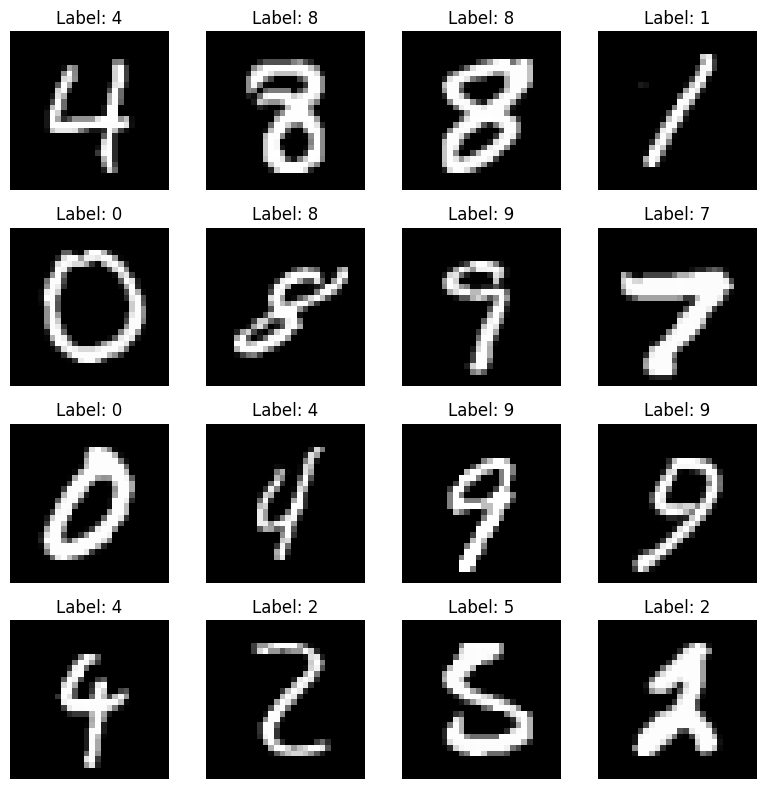

In [8]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_dataloader))  # grab one batch

### YOUR CODE HERE (optional) ###
# Plot a 4×4 grid of images with their labels as titles
# Hint: images[i].squeeze() removes the channel dim → shape (28,28)
# Hint: use cmap='gray' in imshow

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## Step 5 — Define the Model

You'll build a **Multi-Layer Perceptron (MLP)** as a PyTorch `nn.Module`.

### Architecture:
```
Input: 784 (= 28×28 flattened)
  → Linear(784, hidden_dim)
  → ReLU
  → BatchNorm1d(hidden_dim)
  → Dropout(p)
  → Linear(hidden_dim, hidden_dim // 2)
  → ReLU
  → BatchNorm1d(hidden_dim // 2)
  → Dropout(p)
  → Linear(hidden_dim // 2, 10)   ← 10 output classes
Output: raw logits (no softmax — CrossEntropyLoss handles that)
```

### Key concepts:
- **`nn.Sequential`**: chains layers — output of layer N is input to layer N+1
- **`BatchNorm1d`**: normalizes activations within a batch → stabilizes training
- **`Dropout`**: randomly zeros neurons → prevents overfitting
- **`forward(x)`**: must flatten the image first! An image is `(B, 1, 28, 28)` but `nn.Linear` expects `(B, 784)`. Use `x.view(x.size(0), -1)`.

### Pseudocode:
```python
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        self.model = nn.Sequential(
            # Block 1
            Linear → ReLU → BatchNorm → Dropout,
            # Block 2 (half the width)
            Linear → ReLU → BatchNorm → Dropout,
            # Output
            Linear
        )

    def forward(self, x):
        x = flatten(x)  # (B,1,28,28) → (B,784)
        return self.model(x)
```

In [9]:
### YOUR CODE HERE ###
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim,hidden_dim//2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim//2),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim//2,output_dim),
        )

    def forward(self, x):
        # Flatten: (B, 1, 28, 28) → (B, 784)
        x = x.view(x.size(0),-1)
        return self.model(x)


# Instantiate the model and move to device
model = MLP(
    input_dim  = 784,
    hidden_dim = CONFIG['hidden_dim'],
    output_dim = 10,
    dropout    = CONFIG['dropout'],
).to(device)

print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model Parameters: 235,914


### ✅ Sanity Check 4 — Model Architecture

In [11]:
# SANITY CHECK — do not modify
import torch as _torch

# 1. Run a dummy forward pass
model.eval()
dummy = _torch.randn(8, 1, 28, 28).to(device)  # batch of 8 fake images
with _torch.no_grad():
    out = model(dummy)

# 2. Check output shape: should be (batch_size, 10)
assert out.shape == (8, 10), f"Expected (8,10), got {out.shape}"

# 3. Output should NOT be probabilities (no softmax) — values can be negative
# If all values are in [0,1] and sum to 1, you accidentally added softmax
assert not (_torch.all(out >= 0) and _torch.allclose(out.sum(dim=1), _torch.ones(8).to(device))), \
    "Outputs look like probabilities — remove softmax from forward(). CrossEntropyLoss expects raw logits."

# 4. Model is on the right device
param_device = next(model.parameters()).device
assert param_device.type == device.type, f"Model is on {param_device}, expected {device}"

# 5. Parameter count sanity (roughly 200k–300k for this config)
n_params = sum(p.numel() for p in model.parameters())
assert 100_000 < n_params < 1_000_000, f"Param count {n_params:,} seems off — check your layer sizes"

print(f"✅ Sanity Check 4 passed")
print(f"   Output shape: {out.shape}")
print(f"   Output range: [{out.min():.2f}, {out.max():.2f}] (raw logits — can be negative ✓)")
print(f"   Parameters:   {n_params:,}")

✅ Sanity Check 4 passed
   Output shape: torch.Size([8, 10])
   Output range: [-0.24, 0.26] (raw logits — can be negative ✓)
   Parameters:   235,914


---
## Step 6 — Loss, Optimizer & Scheduler

Three separate objects to define:

### Loss function
Use `nn.CrossEntropyLoss()`. It combines `LogSoftmax` + `NLLLoss` internally, which is why your model should output **raw logits** (no softmax).

### Optimizer
Use `optim.Adam(model.parameters(), lr=...)`.  
Adam is the go-to default — it adapts the learning rate per parameter and converges faster than plain SGD on most tasks.

### LR Scheduler
Use `optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)`.  
This halves the learning rate every 5 epochs. A decaying LR helps the model converge to a better minimum in later epochs.

> **Call order matters:** `scheduler.step()` must be called **after** `optimizer.step()` — and in this project, once per epoch at the end of the epoch loop.

In [12]:
### YOUR CODE HERE ###
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=CONFIG['learning_rate'])
scheduler = optim.lr_scheduler.StepLR(optimizer,step_size=5,gamma=0.5)

print(f"Optimizer: {type(optimizer).__name__} | Initial LR: {optimizer.param_groups[0]['lr']}")
print(f"Scheduler: {type(scheduler).__name__}")

Optimizer: Adam | Initial LR: 0.001
Scheduler: StepLR


### ✅ Sanity Check 5 — Loss / Optimizer / Scheduler

In [13]:
# SANITY CHECK — do not modify
import torch as _torch

# 1. Loss on random logits should be near log(10) ≈ 2.302 (uniform distribution baseline)
dummy_logits = _torch.randn(32, 10).to(device)
dummy_labels = _torch.randint(0, 10, (32,)).to(device)
dummy_loss = criterion(dummy_logits, dummy_labels)
assert 1.5 < dummy_loss.item() < 4.0, \
    f"Random baseline loss is {dummy_loss:.3f} — expected ~2.3 (log 10). Check your criterion."

# 2. Optimizer should reference the model's parameters
opt_params = sum(p.numel() for group in optimizer.param_groups for p in group['params'])
model_params = sum(p.numel() for p in model.parameters())
assert opt_params == model_params, \
    f"Optimizer has {opt_params} params but model has {model_params} — did you pass model.parameters()?"

# 3. Scheduler linked to optimizer
assert scheduler.optimizer is optimizer, "Scheduler is not linked to the optimizer"

print(f"✅ Sanity Check 5 passed")
print(f"   Baseline random loss: {dummy_loss.item():.4f} (expected ~2.302 for 10 classes)")
print(f"   Optimizer tracks {opt_params:,} parameters ✓")

✅ Sanity Check 5 passed
   Baseline random loss: 2.6163 (expected ~2.302 for 10 classes)
   Optimizer tracks 235,914 parameters ✓


---
## Step 7 — Weights & Biases Setup

W&B is a free experiment tracking tool. It logs metrics, visualizes training curves, and saves your config — invaluable when running multiple experiments.

**Two calls to make:**

1. `wandb.init(project, config, name)` — starts a new run
   - `project='mnist'` — groups all MNIST experiments together
   - `config=CONFIG` — saves your hyperparameters
   - `name='mlp_baseline'` — human-readable run name

2. `wandb.watch(model, log='gradients', log_freq=100)` — tracks gradient norms (useful for detecting exploding/vanishing gradients)

> If you don't have a W&B account yet, run `wandb login` in your terminal first. Or use `mode='disabled'` to skip logging while testing.

In [14]:
### YOUR CODE HERE ###
# Initialize W&B
wandb.init(
    project = 'mnist',
    config=CONFIG,
    name='mlp_baseline'
)

# Watch model gradients
wandb.watch(model,log='gradients',log_freq=100)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/zichenliu/.netrc.
wandb: Currently logged in as: zliu2263 (zliu2263-university-of-wisconsin-madison) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


---
## Step 8 — Training Loop (One Epoch)

This is the heart of the notebook. Write a function `train_one_epoch(epoch)` that:

1. Sets model to **train mode** (`model.train()`) — enables Dropout and BatchNorm tracking
2. Iterates over `train_dataloader`
3. For each batch:
   - Move `images` and `labels` to `device`
   - Zero the gradients (`optimizer.zero_grad()`)
   - Forward pass → `logits`
   - Compute `loss = criterion(logits, labels)`
   - Backward pass (`loss.backward()`)
   - Clip gradients: `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)`
   - Step the optimizer
4. Accumulate `total_loss`, `correct`, `total` for epoch-level metrics
5. Every 100 batches: log `train/batch_loss` to W&B
6. Return `avg_loss, accuracy`

**Gradient clipping:** Caps the norm of all gradients at 1.0. Not critical for this MLP, but it's a professional habit — essential for RNNs and Transformers.

**Pseudocode:**
```
model.train()
total_loss, correct, total = 0, 0, 0

for batch_idx, (images, labels) in enumerate(train_dataloader):
    move images, labels to device
    zero_grad
    logits = model(images)
    loss = criterion(logits, labels)
    loss.backward()
    clip_grad_norm
    optimizer.step()

    accumulate stats
    if batch_idx % 100 == 0: log to wandb

return avg_loss, accuracy
```

In [19]:
### YOUR CODE HERE ###
def train_one_epoch(epoch):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(train_dataloader):
        # 1. Move to device
        images,labels=images.to(device),labels.to(device)
        # 2. Zero gradients
        optimizer.zero_grad()
        # 3. Forward pass
        logits=model(images)
        # 4. Compute loss
        loss = criterion(logits,labels)
        # 5. Backward pass
        loss.backward()
        # 6. Clip gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
        # 7. Optimizer step
        optimizer.step()
        # 8. Accumulate stats
        # Hint: total_loss += loss.item() * images.size(0)  ← why multiply? to undo the mean
        # Hint: preds = logits.argmax(dim=1)
        total_loss += loss.item()*images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds==labels).sum().item()
        total += images.size(0)

        # 9. Log to W&B every 100 batches
        if batch_idx % 100 == 0:
            wandb.log({
                'train/batch_loss': loss.item(),
                'train/step': epoch * len(train_dataloader) + batch_idx
            })

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

### ✅ Sanity Check 6 — One Training Epoch

In [20]:
# SANITY CHECK — do not modify
# Run a single epoch and check outputs are sane

print("Running one training epoch (this may take ~10–30s)...")
train_loss, train_acc = train_one_epoch(epoch=1)

assert isinstance(train_loss, float), "train_loss should be a Python float"
assert isinstance(train_acc, float), "train_acc should be a Python float"
assert 0.0 < train_loss < 3.0, f"Loss {train_loss:.4f} out of expected range — check accumulation logic"
assert 0.5 < train_acc < 1.0, \
    f"Accuracy {train_acc:.4f} too low after 1 epoch — a random model gets ~0.10, should be well above 0.50"

print(f"✅ Sanity Check 6 passed")
print(f"   Train loss: {train_loss:.4f} | Train accuracy: {train_acc:.4f}")
print(f"   (If accuracy > 0.85 after 1 epoch, your model is working great!)")

Running one training epoch (this may take ~10–30s)...
✅ Sanity Check 6 passed
   Train loss: 0.2079 | Train accuracy: 0.9376
   (If accuracy > 0.85 after 1 epoch, your model is working great!)


---
## Step 9 — Validation Loop

Write an `evaluate()` function. It's similar to training but with two key differences:

1. `model.eval()` — disables Dropout and switches BatchNorm to use running statistics (not batch stats)
2. `torch.no_grad()` — disables gradient computation (saves memory, speeds things up)

No `optimizer.step()` or `backward()` here — you're just measuring, not learning.

**Pseudocode:**
```
model.eval()
with torch.no_grad():
    for images, labels in val_dataloader:
        move to device
        logits = model(images)
        loss = criterion(logits, labels)
        accumulate stats

return avg_loss, accuracy
```

In [21]:
### YOUR CODE HERE ###
def evaluate():
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_dataloader:
            # 1. Move to device
            images,labels = images.to(device),labels.to(device)
            # 2. Forward pass
            logits = model(images)
            # 3. Compute loss
            loss = criterion(logits,labels)
            # 4. Accumulate stats
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * images.size(0)
            correct += (preds==labels).sum().item()
            total += images.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

### ✅ Sanity Check 7 — Validation Loop

In [22]:
# SANITY CHECK — do not modify
import torch as _torch

print("Running validation...")
val_loss, val_acc = evaluate()

assert isinstance(val_loss, float)
assert isinstance(val_acc, float)
assert 0.0 < val_loss < 3.0, f"Val loss {val_loss:.4f} looks off"
assert 0.5 < val_acc < 1.0, f"Val accuracy {val_acc:.4f} unexpectedly low"

# Check model is back in eval mode (it should stay eval after evaluate())
# Also verify no gradients were created by checking a param's grad
for p in model.parameters():
    if p.grad is not None:
        # Grads from training epoch exist, but no NEW ones from evaluate()
        # This is expected — just make sure you used torch.no_grad()
        break

print(f"✅ Sanity Check 7 passed")
print(f"   Val loss: {val_loss:.4f} | Val accuracy: {val_acc:.4f}")

Running validation...
✅ Sanity Check 7 passed
   Val loss: 0.1307 | Val accuracy: 0.9663


---
## Step 10 — Full Training Loop

Now wire everything together. This is the outer loop that runs for `CONFIG['epochs']` epochs.

Each epoch should:
1. Call `train_one_epoch(epoch)` → get `train_loss, train_acc`
2. Call `evaluate()` → get `val_loss, val_acc`
3. Step the scheduler (`scheduler.step()`)
4. Log epoch metrics to W&B: `epoch`, `train/loss`, `train/accuracy`, `val/loss`, `val/accuracy`, `lr`
5. Print a progress line
6. If `val_acc > best_val_acc`: save the model with `torch.save(model.state_dict(), 'best_model.pt')`

After the loop:
- Log `best_val_accuracy` to `wandb.summary`
- Call `wandb.finish()`

**Getting the current LR from the scheduler:**
```python
scheduler.get_last_lr()[0]  # returns a list; take the first element
```

**Saving model state:**
```python
torch.save(model.state_dict(), 'best_model.pt')
```
We save `state_dict()` (weights only), not the entire model object — it's smaller and more portable.

In [23]:
### YOUR CODE HERE ###
best_val_acc = 0.0

for epoch in range(1, CONFIG['epochs'] + 1):
    # 1. Train
    train_loss,train_acc = train_one_epoch(epoch)
    # 2. Validate
    val_loss,val_acc = evaluate()
    # 3. Step scheduler
    scheduler.step()
    # 4. Log to W&B
    wandb.log({
        'epoch':          epoch,
        "train/loss":     train_loss,
        "train/accuracy": train_acc,
        "val/loss":       val_loss,
        'lr':             scheduler.get_last_lr()[0]
        # ... fill in the rest
    })

    # 5. Print progress
    print(
        f"Epoch {epoch:02d}/{CONFIG['epochs']} | "
        # ... fill in train/val metrics
        f"Train loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}  acc: {val_acc:.4f}"
    )

    # 6. Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"  ✓ New best val accuracy: {best_val_acc:.4f} — model saved")


# Finish
print(f"\nTraining complete. Best val accuracy: {best_val_acc:.4f}")
wandb.summary['best_val_accuracy'] = best_val_acc
wandb.finish()

Epoch 01/10 | Train loss: 0.1808  acc: 0.9450 | Val loss: 0.1062  acc: 0.9698
  ✓ New best val accuracy: 0.9698 — model saved
Epoch 02/10 | Train loss: 0.1570  acc: 0.9520 | Val loss: 0.1169  acc: 0.9740
  ✓ New best val accuracy: 0.9740 — model saved
Epoch 03/10 | Train loss: 0.1467  acc: 0.9549 | Val loss: 0.1927  acc: 0.9751
  ✓ New best val accuracy: 0.9751 — model saved
Epoch 04/10 | Train loss: 0.1361  acc: 0.9601 | Val loss: 0.0890  acc: 0.9752
  ✓ New best val accuracy: 0.9752 — model saved
Epoch 05/10 | Train loss: 0.1251  acc: 0.9615 | Val loss: 0.0722  acc: 0.9784
  ✓ New best val accuracy: 0.9784 — model saved
Epoch 06/10 | Train loss: 0.1031  acc: 0.9681 | Val loss: 0.0768  acc: 0.9800
  ✓ New best val accuracy: 0.9800 — model saved
Epoch 07/10 | Train loss: 0.0947  acc: 0.9704 | Val loss: 0.0675  acc: 0.9812
  ✓ New best val accuracy: 0.9812 — model saved
Epoch 08/10 | Train loss: 0.0946  acc: 0.9706 | Val loss: 0.1014  acc: 0.9796
Epoch 09/10 | Train loss: 0.0892  acc: 0

epoch,▁▂▃▃▄▅▆▆▇█
lr,████▃▃▃▃▃▁
train/accuracy,▁▃▃▅▅▇▇▇██
train/batch_loss,█▂▁▃▂▁▂▁▁▁▁▁▁▁▁▂▁▂▂▁▁▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁
train/loss,█▆▅▅▄▂▂▂▁▁
train/step,▁▁▂▁▁▁▁▂▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇█
val/loss,▃▄█▂▁▂▁▃▁▁
best_val_accuracy,0.9815
epoch,10
lr,0.00025
train/accuracy,0.97313


### ✅ Final Sanity Check — Results

Run this after training completes to verify you hit a reasonable result.

In [24]:
# SANITY CHECK — do not modify
import os as _os

# 1. Best val acc should be above 97% (MNIST is an 'easy' benchmark)
assert best_val_acc > 0.95, \
    f"Best val accuracy {best_val_acc:.4f} is below 95% — something may be wrong. Check your training loop."

# 2. Model checkpoint should exist
assert _os.path.exists('best_model.pt'), "best_model.pt not found — was the save logic triggered?"

# 3. Load the checkpoint and verify it works
import torch as _torch
state = _torch.load('best_model.pt', map_location=device)
model.load_state_dict(state)
final_val_loss, final_val_acc = evaluate()
assert abs(final_val_acc - best_val_acc) < 0.001, \
    "Loaded model accuracy doesn't match best_val_acc — save/load mismatch"

print(f"✅ Final Sanity Check passed!")
print(f"   Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"   Model checkpoint loads and verifies correctly ✓")
print(f"\n🎉 You're done! Copy all non-sanity-check code to mnist_mlp.py and run it end-to-end.")

✅ Final Sanity Check passed!
   Best validation accuracy: 0.9815 (98.15%)
   Model checkpoint loads and verifies correctly ✓

🎉 You're done! Copy all non-sanity-check code to mnist_mlp.py and run it end-to-end.


---
## 📋 When You're Done

1. Copy all your code cells (skip the sanity check cells) into a `mnist_mlp.py` file
2. Run it end-to-end: `python mnist_mlp.py`
3. Paste the printed output back here and we'll discuss:
   - How did accuracy change epoch by epoch?
   - Did the LR schedule help?
   - Was there a gap between train and val accuracy? (a sign of overfitting)
   - What would you change to get above 98%?

---
## 💡 Things to Think About While You Code

- Why do we call `optimizer.zero_grad()` at the *start* of each batch, not the end?
- Why does `loss.item()` return a Python float, not a tensor?
- Why do we multiply `loss.item() * images.size(0)` when accumulating total loss?
- What's the difference between `model.train()` and `model.eval()` at the code level?
- Why save `model.state_dict()` instead of the whole `model`?

Bring any of these to our post-training discussion!